In [1]:
# ## install finrl library
!pip install wrds
!pip install swig
!pip install -q condacolab
import condacolab
condacolab.install()
!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.9 MB/s eta 0:00:00
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:20
🔁 Restarting kernel...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libgl1-mesa-glx:amd64.
(Reading database ... 124926 files and directories currently installed.)
Preparing to unpack .../libgl1-mesa-glx_23.0.4-0ubuntu1~22.04.1_amd64.deb ...
Unpacking libgl1-mesa-glx:amd64 (23.0.4-0ubuntu1~22.04.1) ...
Selecting previously unselected package swig4.0.
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.

In [1]:
import warnings
warnings.filterwarnings("ignore")


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

%matplotlib inline
from finrl.config_tickers import DOW_30_TICKER
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent,DRLEnsembleAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline

from pprint import pprint

import sys
sys.path.append("../FinRL-Library")

import itertools

/usr/local/lib/python3.11/site-packages/pandas_datareader/compat/__init__.py:11: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  PANDAS_VERSION = LooseVersion(pd.__version__)


In [3]:
import os
from finrl.main import check_and_make_directories
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)

check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

In [4]:
df = pd.read_csv('data.csv')

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [5]:
 INDICATORS = ['macd',
               'rsi_30',
               'cci_30',
               'dx_30']

In [6]:
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
fe = FeatureEngineer(use_technical_indicator=True,
                     tech_indicator_list = INDICATORS,
                     use_turbulence=True,
                     user_defined_feature = False)

processed = fe.preprocess_data(df)

Successfully added technical indicators
Successfully added turbulence index


In [7]:
df.head()

,date,close,high,low,open,volume,tic,day,daily_return
0,2004-01-01,0.105000,0.105000,0.105000,0.105000,0,DYA.TO,3,NaN
1,2004-01-01,1.378000,1.378000,1.378000,1.378000,0,EDT.TO,3,12.123810
2,2004-01-01,0.300000,0.300000,0.300000,0.300000,0,TSK.TO,3,-0.782293
3,2004-01-02,0.489625,0.489625,0.489625,0.489625,0,AAB.TO,4,0.632084
4,2004-01-02,22.070263,22.211644,21.817266,21.899118,413000,ABX.TO,4,44.075824


In [9]:
len(df)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


4066965

In [10]:
stock_dimension = len(processed.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 3, State Space: 19


In [11]:
env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "buy_cost_pct": 0.001,
    "sell_cost_pct": 0.001,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "print_verbosity":5

}


In [12]:
df.head()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,date,close,high,low,open,volume,tic,day,daily_return
0,2004-01-01,0.105000,0.105000,0.105000,0.105000,0,DYA.TO,3,NaN
1,2004-01-01,1.378000,1.378000,1.378000,1.378000,0,EDT.TO,3,12.123810
2,2004-01-01,0.300000,0.300000,0.300000,0.300000,0,TSK.TO,3,-0.782293
3,2004-01-02,0.489625,0.489625,0.489625,0.489625,0,AAB.TO,4,0.632084
4,2004-01-02,22.070263,22.211644,21.817266,21.899118,413000,ABX.TO,4,44.075824


In [15]:
df.date.value_counts()

,count
date,
2024-12-30,1621
2024-12-02,1620
2024-12-13,1619
2024-12-20,1618
2024-12-05,1618
...,...
2004-09-06,3
2004-10-11,3
2004-12-27,3


In [16]:
df.date.info()

<class 'pandas.core.series.Series'>
RangeIndex: 4066965 entries, 0 to 4066964
Series name: date
Non-Null Count    Dtype 
--------------    ----- 
4066965 non-null  object
dtypes: object(1)
memory usage: 31.0+ MB


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [19]:
(len(df) * 0.8)

3253572.0

In [18]:
df = df.sort_values(by='date').reset_index(drop=True)

In [22]:
split_idx = int(len(df) * 0.8)

In [23]:
# Extract training and validation periods directly
TRAIN_START_DATE = df.iloc[0]['date']
TRAIN_END_DATE = df.iloc[split_idx - 1]['date']

TEST_START_DATE = df.iloc[split_idx]['date']
TEST_END_DATE = df.iloc[-1]['date']

In [24]:
rebalance_window = 63 # rebalance_window is the number of days to retrain the model
validation_window = 63 # validation_window is the number of days to do validation and trading (e.g. if validation_window=63, then both validation and trading period will be 63 days)

ensemble_agent = DRLEnsembleAgent(df=processed,
                 train_period=(TRAIN_START_DATE,TRAIN_END_DATE),
                 val_test_period=(TEST_START_DATE,TEST_END_DATE),
                 rebalance_window=rebalance_window,
                 validation_window=validation_window,
                 **env_kwargs)

In [25]:
SAC_model_kwargs = {
    "batch_size": 64,
    "buffer_size": 100000,
    "learning_rate": 0.0001,
    "learning_starts": 100,
    "ent_coef": "auto_0.1",
}

In [26]:

sac_timesteps = {'sac' : 10_000
                 }

In [31]:
df_summary = ensemble_agent.run_ensemble_strategy(
    A2C_model_kwargs={},  # Empty since we're not using A2C
    PPO_model_kwargs={},  # Empty since we're not using PPO
    DDPG_model_kwargs={},  # Empty since we're not using DDPG
    SAC_model_kwargs=SAC_model_kwargs,  # Your SAC settings
    TD3_model_kwargs={},  # Empty since we're not using TD3
    timesteps_dict={'a2c': 0, 'ppo': 0, 'ddpg': 0, 'sac': 10_000, 'td3': 0}  # Only SAC is active
)


============Start Ensemble Strategy============
turbulence_threshold:  29.78198517472737
======Model training from:  2004-01-01 to  2022-10-18
======a2c Training========
{}
Using cpu device
Logging to tensorboard_log/a2c/a2c_126_1


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


======a2c Validation from:  2022-10-18 to  2023-01-18
a2c Sharpe Ratio:  -0.01742798840251829
======ddpg Training========
{}
Using cpu device
Logging to tensorboard_log/ddpg/ddpg_126_1
======ddpg Validation from:  2022-10-18 to  2023-01-18
ddpg Sharpe Ratio:  0.32156865274371266
======td3 Training========
{}
Using cpu device
Logging to tensorboard_log/td3/td3_126_1
======td3 Validation from:  2022-10-18 to  2023-01-18
td3 Sharpe Ratio:  0.3049606559016455
======sac Training========
{'batch_size': 64, 'buffer_size': 100000, 'learning_rate': 0.0001, 'learning_starts': 100, 'ent_coef': 'auto_0.1'}
Using cpu device
Logging to tensorboard_log/sac/sac_126_1
day: 4727, episode: 5
begin_total_asset: 1000000.00
end_total_asset: 859760.44
total_reward: -140239.56
total_cost: 447.05
total_trades: 4727
Sharpe: 0.076
======sac Validation from:  2022-10-18 to  2023-01-18
sac Sharpe Ratio:  0.24440871025010194
======ppo Training========
{}
Using cpu device
Logging to tensorboard_log/ppo/ppo_126_1
===

In [32]:
unique_trade_date = processed[(processed.date > TEST_START_DATE)&(processed.date <= TEST_END_DATE)].date.unique()

In [34]:
# Assuming unique_trade_date and rebalance_window are defined
df_trade_date = pd.DataFrame({'datadate': unique_trade_date})

# Initialize an empty DataFrame for account values
df_account_value = pd.DataFrame()

for i in range(rebalance_window + validation_window, len(unique_trade_date) + 1, rebalance_window):
    temp = pd.read_csv(f'results/account_value_trade_ensemble_{i}.csv')
    # Use pd.concat() instead of .append()
    df_account_value = pd.concat([df_account_value, temp], ignore_index=True)

# Calculate Sharpe ratio
sharpe = (252**0.5) * df_account_value['account_value'].pct_change(1).mean() / df_account_value['account_value'].pct_change(1).std()
print('Sharpe Ratio:', sharpe)

# Join account value data with trade dates
df_account_value = df_account_value.join(df_trade_date[validation_window:].reset_index(drop=True))


Sharpe Ratio: 0.23564857340822026


In [35]:
df_account_value.head()

,account_value,date,daily_return,datadate
0,1.000000e+06,2023-01-18,NaN,2023-01-18
1,9.999959e+05,2023-01-19,-0.000004,2023-01-19
2,1.000001e+06,2023-01-20,0.000005,2023-01-20
3,9.999917e+05,2023-01-23,-0.000009,2023-01-23
4,9.999476e+05,2023-01-24,-0.000044,2023-01-24


<Axes: >

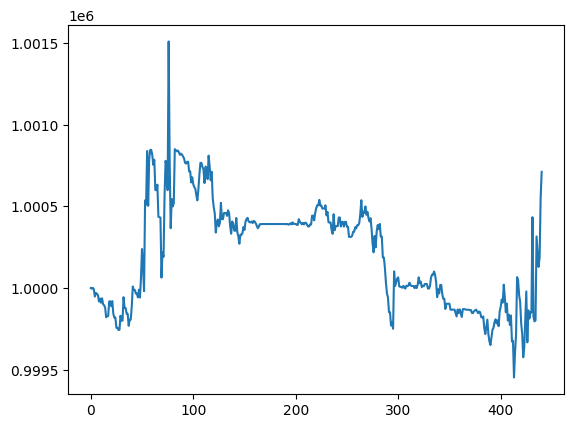

In [36]:
%matplotlib inline
df_account_value.account_value.plot()

In [37]:
print("==============Get Backtest Results===========")
now = datetime.datetime.now().strftime('%Y%m%d-%Hh%M')

perf_stats_all = backtest_stats(account_value=df_account_value)
perf_stats_all = pd.DataFrame(perf_stats_all)

==============Get Backtest Results===========
Annual return          0.000407
Cumulative returns     0.000712
Annual volatility      0.001736
Sharpe ratio           0.235649
Calmar ratio           0.197784
Stability              0.217180
Max drawdown          -0.002057
Omega ratio            1.066059
Sortino ratio          0.374935
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.265442
Daily value at risk   -0.000217
dtype: float64


In [38]:
#baseline stats
print("==============Get Baseline Stats===========")
df_dji_ = get_baseline(
        ticker="^DJI",
        start = df_account_value.loc[0,'date'],
        end = df_account_value.loc[len(df_account_value)-1,'date'])

stats = backtest_stats(df_dji_, value_col_name = 'close')

==============Get Baseline Stats===========


[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (441, 8)
Annual return          0.161023
Cumulative returns     0.298589
Annual volatility      0.109393
Sharpe ratio           1.422915
Calmar ratio           1.785622
Stability              0.875041
Max drawdown          -0.090178
Omega ratio            1.261473
Sortino ratio          2.099403
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.083277
Daily value at risk   -0.013165
dtype: float64


In [39]:
df_dji = pd.DataFrame()
df_dji['date'] = df_account_value['date']
df_dji['dji'] = df_dji_['close'] / df_dji_['close'][0] * env_kwargs["initial_amount"]
print("df_dji: ", df_dji)
df_dji.to_csv("df_dji.csv")
df_dji = df_dji.set_index(df_dji.columns[0])
print("df_dji: ", df_dji)
df_dji.to_csv("df_dji+.csv")

df_account_value.to_csv('df_account_value.csv')

df_dji:             date           dji
0    2023-01-18  1.000000e+06
1    2023-01-19  9.924197e+05
2    2023-01-20  1.002358e+06
3    2023-01-23  1.009989e+06
4    2023-01-24  1.013124e+06
..          ...           ...
436  2024-10-11  1.287320e+06
437  2024-10-15  1.293368e+06
438  2024-10-16  1.283613e+06
439  2024-10-17  1.293743e+06
440  2024-10-18  1.298589e+06

[441 rows x 2 columns]
df_dji:                       dji
date                    
2023-01-18  1.000000e+06
2023-01-19  9.924197e+05
2023-01-20  1.002358e+06
2023-01-23  1.009989e+06
2023-01-24  1.013124e+06
...                  ...
2024-10-11  1.287320e+06
2024-10-15  1.293368e+06
2024-10-16  1.283613e+06
2024-10-17  1.293743e+06
2024-10-18  1.298589e+06

[441 rows x 1 columns]


df_result_ensemble.columns:  Index(['ensemble'], dtype='object')
df_trade_date:         datadate
0    2022-10-18
1    2022-10-19
2    2022-10-20
3    2022-10-21
4    2022-10-24
..          ...
548  2024-12-20
549  2024-12-23
550  2024-12-24
551  2024-12-27
552  2024-12-30

[553 rows x 1 columns]
df_result_ensemble:                  ensemble
date                    
2023-01-18  1.000000e+06
2023-01-19  9.999959e+05
2023-01-20  1.000001e+06
2023-01-23  9.999917e+05
2023-01-24  9.999476e+05
...                  ...
2024-10-11  1.000218e+06
2024-10-15  1.000129e+06
2024-10-16  1.000189e+06
2024-10-17  1.000555e+06
2024-10-18  1.000712e+06

[441 rows x 1 columns]
==============Compare to DJIA===========
result:                  ensemble           dji
date                                  
2023-01-18  1.000000e+06  1.000000e+06
2023-01-19  9.999959e+05  9.924197e+05
2023-01-20  1.000001e+06  1.002358e+06
2023-01-23  9.999917e+05  1.009989e+06
2023-01-24  9.999476e+05  1.013124e+06
...       

<Figure size 1500x500 with 0 Axes>

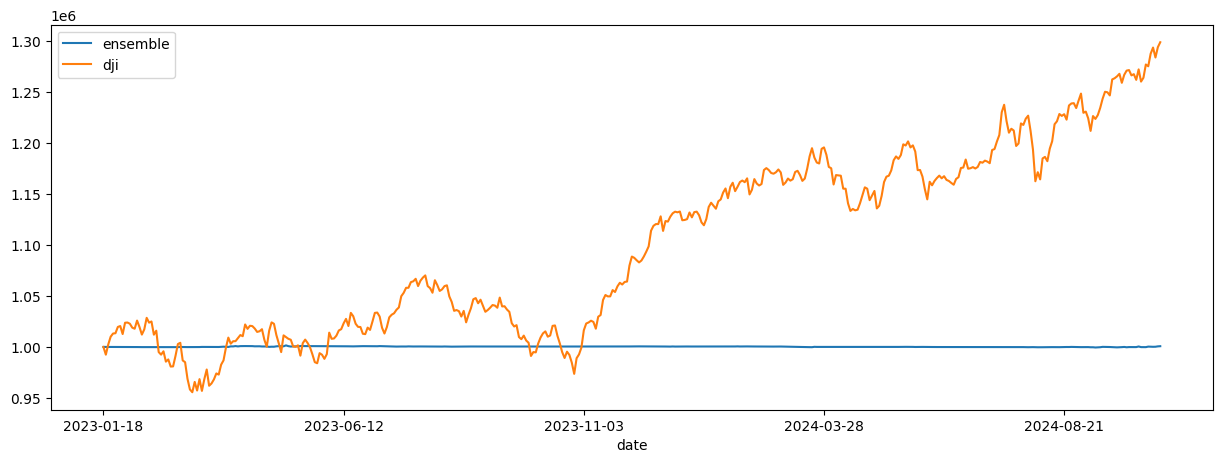

In [40]:
# print("==============Compare to DJIA===========")
# %matplotlib inline
# # S&P 500: ^GSPC
# # Dow Jones Index: ^DJI
# # NASDAQ 100: ^NDX
# backtest_plot(df_account_value,
#               baseline_ticker = '^DJI',
#               baseline_start = df_account_value.loc[0,'date'],
#               baseline_end = df_account_value.loc[len(df_account_value)-1,'date'])
df.to_csv("df.csv")
df_result_ensemble = pd.DataFrame({'date': df_account_value['date'], 'ensemble': df_account_value['account_value']})
df_result_ensemble = df_result_ensemble.set_index('date')

print("df_result_ensemble.columns: ", df_result_ensemble.columns)

# df_result_ensemble.drop(df_result_ensemble.columns[0], axis = 1)
print("df_trade_date: ", df_trade_date)
# df_result_ensemble['date'] = df_trade_date['datadate']
# df_result_ensemble['account_value'] = df_account_value['account_value']
df_result_ensemble.to_csv("df_result_ensemble.csv")
print("df_result_ensemble: ", df_result_ensemble)
print("==============Compare to DJIA===========")
result = pd.DataFrame()
# result = pd.merge(result, df_result_ensemble, left_index=True, right_index=True)
# result = pd.merge(result, df_dji, left_index=True, right_index=True)
result = pd.merge(df_result_ensemble, df_dji, left_index=True, right_index=True)
print("result: ", result)
result.to_csv("result.csv")
result.columns = ['ensemble', 'dji']

%matplotlib inline
plt.rcParams["figure.figsize"] = (15,5)
plt.figure();
result.plot();